In [18]:
import pandas as pd
import numpy as np
import datetime
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from torch.utils.tensorboard import SummaryWriter
from tqdm.notebook import tqdm
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, recall_score, f1_score, accuracy_score




In [2]:
class ContinuousValueEmbedding(nn.Module):
    """
    Continuous Value Embedding for time and values.
    """
    def __init__(self, input_dim, embed_dim, activation='tanh'):
        super().__init__()
        self.hidden_dim = int(embed_dim ** 0.5)
        self.W1 = nn.Parameter(torch.empty(input_dim, self.hidden_dim))
        self.b1 = nn.Parameter(torch.zeros(self.hidden_dim))
        self.W2 = nn.Parameter(torch.empty(self.hidden_dim, embed_dim))
        nn.init.xavier_uniform_(self.W1)
        nn.init.xavier_uniform_(self.W2)
        self.activation = torch.tanh if activation == 'tanh' else F.relu

    def forward(self, x):
        x = self.activation(torch.matmul(x, self.W1) + self.b1)
        return torch.matmul(x, self.W2)

class TransformerBlock(nn.Module):
    """
    A single Transformer block for the model.
    """
    def __init__(self, embed_dim, num_heads, ff_dim, dropout):
        super().__init__()
        self.attention = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.feedforward = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, embed_dim)
        )
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, padding_mask):
        attn_mask = ~padding_mask.bool()
        attn_output, _ = self.attention(x, x, x, key_padding_mask=attn_mask)
        x = self.norm1(x + self.dropout(attn_output))
        ff_output = self.feedforward(x)
        return self.norm2(x + self.dropout(ff_output))

class FusionAttention(nn.Module):
    """
    Fusion Attention to aggregate contextual embeddings.
    """
    def __init__(self, embed_dim):
        super().__init__()
        self.W = nn.Parameter(torch.empty(embed_dim, embed_dim))
        self.b = nn.Parameter(torch.zeros(embed_dim))
        self.u = nn.Parameter(torch.empty(embed_dim, 1))
        nn.init.xavier_uniform_(self.W)
        nn.init.xavier_uniform_(self.u)

    def forward(self, x, mask):
        att = torch.tanh(torch.matmul(x, self.W) + self.b)
        scores = torch.matmul(att, self.u).squeeze(-1)
        scores = scores + (1 - mask) * torch.finfo(scores.dtype).min
        weights = F.softmax(scores, dim=-1)
        return weights

class CLSHead(nn.Module):
    """
    Head for CLS token pooling.
    """
    def __init__(self, embed_dim):
        super().__init__()
        self.dense = nn.Linear(embed_dim, embed_dim)
        self.activation = nn.Tanh()

    def forward(self, x):
        x = self.dense(x)
        return self.activation(x)
    
class FrcstHead(nn.Module):
    """
    Head for CLS token pooling.
    """
    def __init__(self, embed_dim, output_dim):
        super().__init__()
        self.lin1 = nn.Linear(embed_dim, embed_dim)
        self.activation = nn.ReLU()
        self.lin2 = nn.Linear(embed_dim, output_dim)

    def forward(self, x):
        x = self.lin1(x)
        x = self.activation(x)
        x = self.lin2(x)
        return x


class STraTSModel_cl(nn.Module):
    """
    Main model definition for the STraTS task.
    """
    def __init__(self, num_features, embed_dim, num_heads, num_blocks, ff_dim, dropout, activation='tanh', use_variable_embedding=True):
        super().__init__()
        self.use_variable_embedding = use_variable_embedding
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, ff_dim, dropout)
            for _ in range(num_blocks)
        ])
        self.fusion_attention = FusionAttention(embed_dim)
        self.time_embed = ContinuousValueEmbedding(input_dim=1, embed_dim=embed_dim, activation=activation)
        self.value_embed = ContinuousValueEmbedding(input_dim=1, embed_dim=embed_dim, activation=activation)
        self.feature_embed = nn.Embedding(num_features + 1, embed_dim)  # +1 for padding
        self.forecast_head = nn.Linear(embed_dim, num_features)
        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(embed_dim)

        # CLS token and heads
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        nn.init.xavier_uniform_(self.cls_token)
        self.cls_head = CLSHead(embed_dim)
        self.similarity = nn.CosineSimilarity(dim=-1)

    def forward(self, times, varis, values, padding_mask, mask_rate=0.2, seed=None, pretrain=False, use_cl=False, use_interp=False):
        # Add CLS token
        bsz = values.size(0)
        cls_tokens = self.cls_token.expand(bsz, -1, -1)  # (bsz, 1, embed_dim)
        time_emb = self.time_embed(times.unsqueeze(-1))
        value_emb = self.value_embed(values.unsqueeze(-1))
        feature_emb = self.feature_embed(varis)

        if use_interp:
            # Apply mask to value embeddings
            rng = torch.Generator()
            rng.manual_seed(seed)
            mask = (torch.rand(values.size(), generator=rng, device=values.device) > mask_rate).float()
            masked_value_emb = value_emb * mask.unsqueeze(-1)

            # Combine embeddings
            triplet_emb = time_emb + masked_value_emb + feature_emb
            triplet_emb = self.dropout(triplet_emb)

            for block in self.transformer_blocks:
                triplet_emb = block(triplet_emb, padding_mask)

            # CLS pooling for contrastive learning
            cls_emb = self.cls_head(triplet_emb[:, 0, :])

            # Apply fusion attention
            fusion_weights = self.fusion_attention(triplet_emb, padding_mask)
            fused_emb = (triplet_emb * fusion_weights.unsqueeze(-1)).sum(dim=1)
            fused_emb = self.layer_norm(fused_emb)

            # Combine CLS Embedding with Fusion Embedding
            unified_emb = (fused_emb + cls_emb) / 2

            # Forecast head to predict masked values
            forecast = self.forecast_head(unified_emb)

            # Compute loss for masked values only
            masked_loss = (1 - mask) * padding_mask
            mse_loss = F.mse_loss(forecast * masked_loss, values * masked_loss)

        if use_cl:
            triplet_emb = time_emb + value_emb + feature_emb
            triplet_emb = self.dropout(triplet_emb)
            triplet_emb = torch.cat([cls_tokens, triplet_emb], dim=1)  # (bsz, seq_len + 1, embed_dim)

            for block in self.transformer_blocks:
                triplet_emb = block(triplet_emb, padding_mask)

            # CLS pooling for contrastive learning
            cls_emb = self.cls_head(triplet_emb[:, 0, :])

            # Apply fusion attention
            fusion_weights = self.fusion_attention(triplet_emb[:, 1:, :], padding_mask)
            fusion_emb = (triplet_emb[:, 1:, :] * fusion_weights.unsqueeze(-1)).sum(dim=1)
            fusion_emb = self.layer_norm(fusion_emb)

            # Combine CLS Embedding with Fusion Embedding
            unified_emb = (fusion_emb + cls_emb) / 2

            # Contrastive Learning
            z1, z2 = unified_emb[:bsz // 2], unified_emb[bsz // 2:]
            cos_sim = self.similarity(z1.unsqueeze(1), z2.unsqueeze(0))
            labels = torch.arange(cos_sim.size(0)).long().to(cos_sim.device)
            cl_loss = F.cross_entropy(cos_sim, labels)

        if pretrain:
            loss = 0
            if use_cl:
                loss += cl_loss
            if use_interp:
                loss += mse_loss
            return {'loss': loss, 'cl_loss': cl_loss if use_cl else None, 'mse_loss': mse_loss if use_interp else None}

        # Downstream task
        return unified_emb if use_cl or use_interp else forecast
    

class STraTSModel(nn.Module):
    """
    Main model definition for the STraTS task.
    """
    def __init__(self, num_features, embed_dim, num_heads, num_blocks, ff_dim,
                 dropout, activation='tanh', final_emb_type='balanced', fusion_emb_weight=0.5):
        super().__init__()

        # ------------------------------
        # (1) Transformer + Embeddings
        # ------------------------------
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, ff_dim, dropout)
            for _ in range(num_blocks)
        ])
        self.fusion_attention = FusionAttention(embed_dim)
        self.time_embed = ContinuousValueEmbedding(input_dim=1, embed_dim=embed_dim, activation=activation)
        self.value_embed = ContinuousValueEmbedding(input_dim=1, embed_dim=embed_dim, activation=activation)
        self.feature_embed = nn.Embedding(num_features + 1, embed_dim)  # +1 for padding

        # pretrain 시계열 예측을 위한 head
        self.forecast_head = FrcstHead(embed_dim, num_features+1)

        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(embed_dim)

        # ------------------------------
        # (2) Downstream heads
        # ------------------------------
        self.linear_saps = nn.Linear(embed_dim, 1)
        self.linear_sofa = nn.Linear(embed_dim, 1)
        self.linear_death = nn.Linear(embed_dim, 1)

        # ------------------------------
        # (3) CLS token & heads
        # ------------------------------
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        nn.init.xavier_uniform_(self.cls_token)
        self.cls_head = CLSHead(embed_dim)
        self.similarity = nn.CosineSimilarity(dim=-1)

        # ------------------------------
        # (4) 설정
        # ------------------------------
        self.final_emb_type = final_emb_type
        self.fusion_emb_weight = fusion_emb_weight

    def forward(self, 
                times, varis, values, padding_mask, 
                mask_rate=0.2, seed=None, pretrain=False, 
                outcomes=None,
                freeze_pretrained=False):
        """
        - pretrain: True  => 마스킹 기반 시계열 예측 (forecast) 수행
        - pretrain: False => downstream (SAPS, SOFA, death) 예측
        - freeze_pretrained: True => pretrain=False 시, pretrain 모듈 파라미터 고정
        """

        # -----------------------------------------
        # 1) if freeze_pretrained and not pretrain
        #    => freeze(Transformer+Embeddings+Forecast_head)
        # -----------------------------------------
        if freeze_pretrained and not pretrain:
            # Transformer Blocks
            for param in self.transformer_blocks.parameters():
                param.requires_grad = False
            for param in self.fusion_attention.parameters():
                param.requires_grad = False

            # Embeddings
            for param in self.time_embed.parameters():
                param.requires_grad = False
            for param in self.value_embed.parameters():
                param.requires_grad = False
            for param in self.feature_embed.parameters():
                param.requires_grad = False

            # Forecast head (pretrain용)
            for param in self.forecast_head.parameters():
                param.requires_grad = False

        # -----------------------------------------
        # 2) 임베딩 + (pretrain 시) 마스킹
        # -----------------------------------------
        bsz, seq_len = values.size()
        cls_tokens = self.cls_token.expand(bsz, -1, -1)  # (bsz, 1, embed_dim)

        time_emb = self.time_embed(times.unsqueeze(-1))
        value_emb = self.value_embed(values.unsqueeze(-1))
        feature_emb = self.feature_embed(varis)

        if pretrain:
            rng = torch.Generator(device=values.device)
            rng.manual_seed(seed)
            mask = (torch.rand(values.size(), generator=rng, device=values.device) > mask_rate).float()
            masked_value_emb = value_emb * mask.unsqueeze(-1)
            triplet_emb = time_emb + masked_value_emb + feature_emb
        else:
            triplet_emb = time_emb + value_emb + feature_emb

        triplet_emb = self.dropout(triplet_emb)
        triplet_emb = torch.cat([cls_tokens, triplet_emb], dim=1)

        cls_padding_mask = torch.ones((bsz, 1), device=padding_mask.device)  # CLS 토큰 위치용
        att_padding_mask = torch.cat([cls_padding_mask, padding_mask], dim=1)
        fus_padding_mask = torch.cat([torch.zeros_like(cls_padding_mask), padding_mask], dim=1)

        # -----------------------------------------
        # 3) Transformer Blocks 통과
        # -----------------------------------------
        for block in self.transformer_blocks:
            triplet_emb = block(triplet_emb, att_padding_mask)

        # CLS pooling
        cls_emb = self.cls_head(triplet_emb[:, 0, :])

        # -----------------------------------------
        # 4) 최종 임베딩 (Fusion vs CLS vs Balanced)
        # -----------------------------------------
        if self.final_emb_type == 'balanced':
            fusion_weights = self.fusion_attention(triplet_emb, fus_padding_mask)
            fusion_emb = (triplet_emb * fusion_weights.unsqueeze(-1)).sum(dim=1)
            fusion_emb = self.layer_norm(fusion_emb)
            final_emb = self.fusion_emb_weight * fusion_emb + (1 - self.fusion_emb_weight) * cls_emb
        elif self.final_emb_type == 'cls':
            final_emb = cls_emb
        elif self.final_emb_type == 'fusion':
            fusion_weights = self.fusion_attention(triplet_emb, fus_padding_mask)
            fusion_emb = (triplet_emb * fusion_weights.unsqueeze(-1)).sum(dim=1)
            fusion_emb = self.layer_norm(fusion_emb)
            final_emb = fusion_emb
        else:
            print(f'Invalid final_emb_type of "{self.final_emb_type}", using default balanced embedding')
            final_emb = cls_emb  # fallback

        # -----------------------------------------
        # 5) Pretrain vs Downstream
        # -----------------------------------------
        if pretrain:
            # (A) Pretrain: 마스킹된 시계열 예측
            triplet_emb_seq = triplet_emb[:, 1:, :]  # CLS 제외
            seq_emb = (2 * triplet_emb_seq + final_emb.unsqueeze(1)) / 3
            forecast = self.forecast_head(seq_emb)    # [bsz, seq_len, num_features+1]
            gather_input = varis.unsqueeze(-1)        # [bsz, seq_len, 1]
            forecast_selected = torch.gather(forecast, 2, gather_input)  # [bsz, seq_len, 1]
            forecast_selected = forecast_selected.squeeze(-1)            # [bsz, seq_len]

            # 마스킹된 위치의 MSE loss
            masked_loss = (1 - mask) * padding_mask
            pred_masked = forecast_selected * masked_loss
            gt_masked = values * masked_loss
            diff = pred_masked - gt_masked
            sq_diff = diff ** 2
            sum_sq_diff = sq_diff.sum()
            sum_masked_loss = masked_loss.sum()

            if sum_masked_loss == 0:
                mse_loss = torch.tensor(0.0, device=values.device)
            else:
                mse_loss = sum_sq_diff / sum_masked_loss

            return {
                'forecast': forecast_selected,
                'values': values,
                'varis': varis,
                'times': times,
                'masks': mask,
                'loss': mse_loss
            }

        else:
            # (B) Downstream: SAPS, SOFA, Death
            pred_saps  = self.linear_saps(final_emb)      # [bsz, 1]
            pred_sofa  = self.linear_sofa(final_emb)      # [bsz, 1]
            pred_death = torch.sigmoid(self.linear_death(final_emb))  # [bsz, 1]

            # outcomes = (bsz, 4): [hadm_id, saps_label, sofa_label, death_label]
            if outcomes is not None:
                hadm_id     = outcomes[:, 0]
                saps_label  = outcomes[:, 1]  # float
                sofa_label  = outcomes[:, 2]  # float
                death_label = outcomes[:, 3]  # 0 or 1

                loss_saps  = F.mse_loss(pred_saps.squeeze(-1), saps_label)
                loss_sofa  = F.mse_loss(pred_sofa.squeeze(-1), sofa_label)
                loss_death = F.binary_cross_entropy(pred_death.squeeze(-1), death_label)
                #total_loss = loss_saps + loss_sofa + loss_death
                total_loss = loss_death

                return {
                    'hadm_id': hadm_id,
                    'pred_saps':  pred_saps,
                    'pred_sofa':  pred_sofa,
                    'pred_death': pred_death,
                    'saps': saps_label,
                    'sofa': sofa_label,
                    'death': death_label,
                    'loss': total_loss,
                    'loss_saps': loss_saps,
                    'loss_sofa': loss_sofa,
                    'loss_death': loss_death
                }
            else:
                # Inference only (no labels)
                return {
                    'pred_saps':  pred_saps,
                    'pred_sofa':  pred_sofa,
                    'pred_death': pred_death
                }

In [3]:
def pretrain_model(model, train_loader, valid_loader, epochs, optimizer, device, 
                   mask_rate=0.2, seed=None, patience=7):
    writer = SummaryWriter()
    model.to(device)
    best_valid_loss = float('inf')
    early_stop_counter = 0
    train_losses = []
    valid_losses = []

    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0

        for batch in tqdm(train_loader, desc=f"[Pretrain] Epoch [{epoch+1}/{epochs}] - Training", leave=False):
            # 예상되는 batch 구조: (times, varis, values, saps, sofa, death, padding_mask)
            # 하지만 pretrain에서는 saps/sofa/death가 필요하지 않으므로 '_'로 받거나 무시.
            hadm_id, times, varis, values, _, _, _, padding_mask = [x.to(device) for x in batch]
            
            optimizer.zero_grad()
            outputs = model(times, varis, values, 
                            padding_mask=padding_mask, 
                            mask_rate=mask_rate, 
                            seed=seed, 
                            pretrain=True)  # <-- pretrain=True
            loss = outputs['loss']

            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        # Validation phase
        valid_loss = 0
        model.eval()
        with torch.no_grad():
            for batch in tqdm(valid_loader, desc=f"[Pretrain] Epoch [{epoch+1}/{epochs}] - Validation", leave=False):
                hadm_id, times, varis, values, _, _, _, padding_mask = [x.to(device) for x in batch]
                outputs = model(times, varis, values, 
                                padding_mask=padding_mask, 
                                mask_rate=mask_rate, 
                                seed=seed, 
                                pretrain=True)
                valid_loss += outputs['loss'].item()
        valid_loss /= len(valid_loader)
        valid_losses.append(valid_loss)

        print(f"[Pretrain] Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Valid Loss = {valid_loss:.4f}")

        # Early stopping
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            torch.save(model.state_dict(), "best_pretrained_model.pt")
            early_stop_counter = 0
        else:
            early_stop_counter += 1

        if early_stop_counter >= patience:
            print("Early stopping triggered (pretrain).")
            break

    writer.close()
    epochs_range = range(1, len(train_losses) + 1)
    plt.figure(figsize=(8, 6))
    plt.plot(epochs_range, train_losses, label='Train Loss')
    plt.plot(epochs_range, valid_losses, label='Valid Loss')
    plt.title('Pretraining Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

def train_model(model, train_loader, valid_loader, epochs, optimizer, device,
                mask_rate=0.2, seed=None, patience=7, freeze=False):
    writer = SummaryWriter()
    model.to(device)
    best_valid_loss = float('inf')
    early_stop_counter = 0

    train_losses = []
    train_saps_losses = []
    train_sofa_losses = []
    train_death_losses = []

    valid_losses = []
    valid_saps_losses = []
    valid_sofa_losses = []
    valid_death_losses = []

    # AUROC / AUPRC 기록용
    valid_aurocs = []
    valid_auprcs = []

    for epoch in range(epochs):
        # ===================================================
        # (1) Training phase
        # ===================================================
        model.train()
        train_loss = 0
        train_saps_loss = 0
        train_sofa_loss = 0
        train_death_loss = 0

        for batch in tqdm(train_loader, desc=f"[Downstream] Epoch [{epoch+1}/{epochs}] - Training", leave=False):
            hadm_id, times, varis, values, saps, sofa, death, padding_mask = [x.to(device) for x in batch]
            
            # outcomes: shape (batch_size, 4) => [hadm_id, saps_label, sofa_label, death_label]
            outcomes = torch.stack([hadm_id, saps, sofa, death], dim=1)

            optimizer.zero_grad()
            # pretrain=False, 전달된 outcomes로 loss 계산
            outputs = model(times, varis, values, 
                            padding_mask=padding_mask, 
                            mask_rate=mask_rate, 
                            seed=seed, 
                            pretrain=False, 
                            outcomes=outcomes)

            loss = outputs['loss']
            loss_saps  = outputs['loss_saps']
            loss_sofa  = outputs['loss_sofa']
            loss_death = outputs['loss_death']

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_saps_loss += loss_saps.item()
            train_sofa_loss += loss_sofa.item()
            train_death_loss += loss_death.item()

        # epoch 단위 평균
        train_loss       /= len(train_loader)
        train_saps_loss  /= len(train_loader)
        train_sofa_loss  /= len(train_loader)
        train_death_loss /= len(train_loader)

        train_losses.append(train_loss)
        train_saps_losses.append(train_saps_loss)
        train_sofa_losses.append(train_sofa_loss)
        train_death_losses.append(train_death_loss)

        # ===================================================
        # (2) Validation phase
        # ===================================================
        valid_loss = 0
        valid_saps_loss = 0
        valid_sofa_loss = 0
        valid_death_loss = 0

        # -----------------------------
        # (a) AUROC/AUPRC 계산 위해 전체 배치 예측/라벨 누적
        # -----------------------------
        death_preds_all = []
        death_labels_all = []

        model.eval()
        with torch.no_grad():
            for batch in tqdm(valid_loader, desc=f"[Downstream] Epoch [{epoch+1}/{epochs}] - Validation", leave=False):
                hadm_id, times, varis, values, saps, sofa, death, padding_mask = [x.to(device) for x in batch]
                outcomes = torch.stack([hadm_id, saps, sofa, death], dim=1)

                outputs = model(times, varis, values, 
                                padding_mask=padding_mask, 
                                mask_rate=mask_rate, 
                                seed=seed, 
                                pretrain=False,
                                freeze_pretrained=freeze, 
                                outcomes=outcomes)

                loss       = outputs['loss']
                loss_saps  = outputs['loss_saps']
                loss_sofa  = outputs['loss_sofa']
                loss_death = outputs['loss_death']

                valid_loss       += loss.item()
                valid_saps_loss  += loss_saps.item()
                valid_sofa_loss  += loss_sofa.item()
                valid_death_loss += loss_death.item()

                # -----------------------
                # (b) death pred & label
                # -----------------------
                # pred_death: (batch_size, 1) => sigmoid output
                # death_label: (batch_size,)
                pred_death  = outputs['pred_death'].squeeze(-1)  # shape: [bsz]
                death_label = outputs['death']  # shape: [bsz]

                # cpu로 옮겨 numpy 변환
                pred_death_np  = pred_death.detach().cpu().numpy()
                death_label_np = death_label.detach().cpu().numpy()

                death_preds_all.append(pred_death_np)
                death_labels_all.append(death_label_np)

        # (c) epoch 단위 평균 Loss
        valid_loss       /= len(valid_loader)
        valid_saps_loss  /= len(valid_loader)
        valid_sofa_loss  /= len(valid_loader)
        valid_death_loss /= len(valid_loader)

        valid_losses.append(valid_loss)
        valid_saps_losses.append(valid_saps_loss)
        valid_sofa_losses.append(valid_sofa_loss)
        valid_death_losses.append(valid_death_loss)

        # -----------------------
        # (d) AUROC / AUPRC 계산
        # -----------------------
        # stack 전체 death 예측/라벨 => shape (N,)
        death_preds_all = np.concatenate(death_preds_all, axis=0)
        death_labels_all = np.concatenate(death_labels_all, axis=0)

        auroc = roc_auc_score(death_labels_all, death_preds_all)
        auprc = average_precision_score(death_labels_all, death_preds_all)

        valid_aurocs.append(auroc)
        valid_auprcs.append(auprc)

        print(f"[Epoch {epoch+1}] Train Loss={train_loss:.4f}, Valid Loss={valid_loss:.4f}, "
              f"Valid AUROC={auroc:.4f}, AUPRC={auprc:.4f}")

        # (e) Early stopping
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            if freeze:
                torch.save(model.state_dict(), "best_frozen_downstream_model_.pt")
            else:
                torch.save(model.state_dict(), "best_downstream_model.pt")
            early_stop_counter = 0
        else:
            early_stop_counter += 1
        if early_stop_counter >= patience:
            print("Early stopping triggered (downstream).")
            break

    writer.close()

    # (3) 에폭별 결과 시각화/데이터프레임 생성
    epochs_range = range(1, len(train_losses) + 1)

    plt.figure(figsize=(8, 6))
    plt.plot(epochs_range, train_losses, label='Train Loss')
    plt.plot(epochs_range, valid_losses, label='Valid Loss')
    plt.title('Downstream Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    # 추가: AUROC, AUPRC 시각화(옵션)
    plt.figure()
    plt.plot(epochs_range, valid_aurocs, label='Valid AUROC')
    plt.plot(epochs_range, valid_auprcs, label='Valid AUPRC')
    plt.title('Death Prediction Metrics')
    plt.xlabel('Epoch')
    plt.ylabel('Metric')
    plt.legend()
    plt.show()

    # (4) DataFrame
    # zip(*...)로 행=epoch, 열=각 metric
    data = list(zip(train_losses, train_saps_losses, train_sofa_losses, train_death_losses,
                    valid_losses, valid_saps_losses, valid_sofa_losses, valid_death_losses,
                    valid_aurocs, valid_auprcs))
    columns = ['Train loss', 'Train SAPS', 'Train SOFA', 'Train DEATH',
               'Valid loss', 'Valid SAPS', 'Valid SOFA', 'Valid DEATH',
               'Valid AUROC', 'Valid AUPRC']
    loss_df = pd.DataFrame(data=data, columns=columns)

    return loss_df

In [4]:
def validate_model(model, valid_loader, device, mask_rate=0.2, seed=None):
    model.eval()
    results = []


    with torch.no_grad():
        for batch in valid_loader:
            hadm_id, times, varis, values, _, _, _, padding_mask = [x.to(device) for x in batch]

            # Forward pass
            outputs = model(times, varis, values, padding_mask, mask_rate=mask_rate, seed=seed, pretrain=True)

            # Gather outputs
            for i in range(times.size(0)):  # Loop through the batch
                result = pd.DataFrame({
                    'hadm_id': hadm_id[i].cpu().numpy().tolist(),
                    'Time': times[i].cpu().numpy().tolist(),
                    'Variable': varis[i].cpu().numpy().tolist(),
                    'True Value': values[i].cpu().numpy().tolist(),
                    'Predicted Value': outputs['forecast'][i].cpu().numpy().tolist(),
                    'Mask': outputs['masks'][i].cpu().numpy().tolist()
                })
                results.append(result)

    # Convert results to a DataFrame
    df = pd.concat(results)
    return df

def validate_model_downstream(model, valid_loader, device, mask_rate=0.2, seed=None):
    results = []
    model.eval()
    with torch.no_grad():
        for batch in valid_loader:
            hadm_id, times, varis, values, saps, sofa, death, padding_mask = [x.to(device) for x in batch]
            outcomes = torch.stack([hadm_id, saps, sofa, death], dim=1)

            outputs = model(times, varis, values, 
                            padding_mask=padding_mask, 
                            mask_rate=mask_rate, 
                            seed=seed, 
                            pretrain=False, 
                            outcomes=outcomes)
            for i in range(hadm_id.size(0)):
                result = pd.DataFrame({
                    'hadm_id': outputs['hadm_id'].cpu().numpy().tolist(),
                    'pred_saps': outputs['pred_saps'].cpu().numpy().tolist(),
                    'pred_sofa': outputs['pred_sofa'].cpu().numpy().tolist(),
                    'pred_death': outputs['pred_death'].cpu().numpy().tolist(),
                    'saps': outputs['saps_label'].cpu().numpy().tolist(),
                    'sofa': outputs['sofa_label'].cpu().numpy().tolist(),
                    'death': outputs['death_label'].cpu().numpy().tolist(),                       
                })
                results.append(result)
    df = pd.concat(results)
    return df

In [19]:
def evaluate_model(model, test_loader, device):
    """
    Test set에 대해 모델 추론 후, 다양한 분류 지표를 계산하는 함수.
    
    모델은 pred_death(= 사망 확률, 0~1)를 반환한다고 가정.
    실제 라벨(0/1)은 death로 가정.
    
    Parameters
    ----------
    model : nn.Module
        학습이 완료된 PyTorch 모델
    test_loader : DataLoader
        테스트 데이터셋 로더 (배치별로 hadm_id, times, varis, values, saps, sofa, death, padding_mask 등 반환)
    device : torch.device
        CUDA 또는 CPU
    
    Returns
    -------
    metrics : dict
        {
          'AUROC': float,
          'AUPRC': float,
          'Precision': float,
          'Recall': float,
          'F1': float,
          'Accuracy': float
        }
    """

    model.eval()  # 추론 모드
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            # 배치 구조 예: hadm_id, times, varis, values, saps, sofa, death, padding_mask
            hadm_id, times, varis, values, saps, sofa, death, padding_mask = [x.to(device) for x in batch]

            # 모델에 전달할 outcomes (hadm_id, saps, sofa, death) - 필요 시 정의
            outcomes = torch.stack([hadm_id, saps, sofa, death], dim=1)

            # 추론
            outputs = model(times, varis, values, padding_mask=padding_mask, 
                            pretrain=False, outcomes=outcomes)

            # 모델이 반환하는 사망 확률 (배치 x 1)
            pred_death = outputs['pred_death'].squeeze(-1)  # (batch_size,)
            # 실제 라벨
            label_death = outputs['death']                  # (batch_size,)

            # CPU로 옮겨서 numpy로 변환
            all_preds.append(pred_death.detach().cpu().numpy())
            all_labels.append(label_death.detach().cpu().numpy())

    # 전체 배치를 합쳐서 (N,) 형태가 됨
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    # AUROC (roc_auc_score), AUPRC (average_precision_score)는 확률값 사용
    auroc = roc_auc_score(all_labels, all_preds)
    auprc = average_precision_score(all_labels, all_preds)

    # Precision, Recall, F1, Accuracy 등은 threshold=0.5로 이진화하여 계산
    pred_binary = (all_preds >= 0.5).astype(int)

    prec = precision_score(all_labels, pred_binary)
    rec  = recall_score(all_labels, pred_binary)
    f1   = f1_score(all_labels, pred_binary)
    acc  = accuracy_score(all_labels, pred_binary)

    metrics = {
        'AUROC': auroc,
        'AUPRC': auprc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'Accuracy': acc
    }

    return metrics

In [5]:
outcome_a = pd.read_feather('pcc2012_a_outcome.feather')
outcome_b = pd.read_feather('pcc2012_b_outcome.feather')
outcome_c = pd.read_feather('pcc2012_c_outcome.feather')
def process_outcome(outcome):
    outcome = outcome.loc[:,['RecordID', 'SAPS-I', 'SOFA', 'In-hospital_death']]
    outcome = outcome.rename(columns={'RecordID': 'hadm_id', 'In-hospital_death' : 'death'})
    outcome = outcome.loc[(outcome.loc[:,'SAPS-I']!= -1) & (outcome.loc[:,'SOFA']!= -1),:]
    unique_outcome_ids = outcome['hadm_id'].unique()
    return outcome, unique_outcome_ids
outcome_a, a_ids = process_outcome(outcome_a)
outcome_b, b_ids = process_outcome(outcome_b)
outcome_c, c_ids = process_outcome(outcome_c)

In [6]:
data_a = pd.read_feather('pcc2012_a.feather')
data_b = pd.read_feather('pcc2012_b.feather')
data_c = pd.read_feather('pcc2012_c.feather')

data = pd.concat([data_a, data_b, data_c])

data = data.rename(columns={'time' : 'offset', 'recordid' : 'hadm_id', 'parameter' : 'itemid'})

# Factorize the 'item' column and get the mapping
encoded, actual_class = pd.factorize(data['itemid'])
data.loc[:,'itemid'] = encoded.astype(int)
data['itemid'] = pd.to_numeric(data['itemid'], errors='coerce')

data = data.dropna(subset=['value'])

item_dict = dict(zip(actual_class, range(len(actual_class))))
emb_idx = len(item_dict)

unique_hadm_ids = np.concatenate([b_ids, c_ids])

# 재현성 유지를 위해 seed를 고정하고 섞습니다.
np.random.seed(42)
np.random.shuffle(unique_hadm_ids)

# 예: 80%를 train, 나머지를 valid로 사용
train_size = int(len(unique_hadm_ids) * 0.8)
train_hadm_ids = unique_hadm_ids[:train_size]
valid_hadm_ids = unique_hadm_ids[train_size:]
test_hadm_ids = a_ids

train_df = data[data['hadm_id'].isin(train_hadm_ids)].copy().reset_index(drop=True)
valid_df = data[data['hadm_id'].isin(valid_hadm_ids)].copy().reset_index(drop=True)
test_df = data[data['hadm_id'].isin(test_hadm_ids)].copy().reset_index(drop=True)

outcome_bc = pd.concat([outcome_b, outcome_c])
train_outcome_df = outcome_bc[outcome_bc['hadm_id'].isin(train_hadm_ids)].copy()
valid_outcome_df = outcome_bc[outcome_bc['hadm_id'].isin(valid_hadm_ids)].copy()
test_outcome_df = outcome_a[outcome_a['hadm_id'].isin(test_hadm_ids)].copy()


scalers_dict = {}  

for item_id, group in train_df.groupby('itemid'):
    scaler = StandardScaler()
    scaled_values = scaler.fit_transform(group['value'].values.reshape(-1, 1))
    
    # group에는 스케일링한 값을 '직접' 넣어봤자 원본은 바뀌지 않음
    # 대신 group.index를 활용해 원본 DF에 반영
    train_df.loc[group.index, 'value'] = scaled_values
    
    scalers_dict[item_id] = scaler

for item_id, group in valid_df.groupby('itemid'):
    scaler = scalers_dict[item_id]  # 이미 학습된 scaler 사용
    scaled_values = scaler.transform(group['value'].values.reshape(-1, 1))
    valid_df.loc[group.index, 'value'] = scaled_values

for item_id, group in test_df.groupby('itemid'):
    scaler = scalers_dict[item_id]  # 이미 학습된 scaler 사용
    scaled_values = scaler.transform(group['value'].values.reshape(-1, 1))
    test_df.loc[group.index, 'value'] = scaled_values

In [17]:
class TimeSeriesDataset(Dataset):
    def __init__(self, df, outcome_df, observation_window, step, mode='train'):
        self.samples = []
        self.observation_window = observation_window
        self.step = step
        self.mode = mode
        lengths = []

        for hadm_id, group in df.groupby('hadm_id'):
            # outcome_df에서 해당 hadm_id의 행만 뽑아오기
            outcome_row = outcome_df.loc[outcome_df['hadm_id'] == hadm_id, ['SAPS-I', 'SOFA', 'death']]

            # 여러 행이 나올 수 있다면 보정(예: 첫 행만 사용) 필요
            saps, sofa, death = outcome_row.values[0]

            max_offset = group['offset'].max()
            query_times = [2880]

            for query_time in query_times:
                obs_window = group[
                    (group['offset'] > query_time - self.observation_window) &
                    (group['offset'] <= query_time)
                ].copy()
                
                if not obs_window.empty and obs_window.shape[0] > 9:
                    obs_window['offset'] = (
                        obs_window['offset'] - (query_time - self.observation_window)
                    )
                    # outcome까지 함께 저장
                    self.samples.append((hadm_id, query_time, obs_window, saps, sofa, death))
                    lengths.append(obs_window.shape[0])
        
                # 샘플 시퀀스 길이들의 평균, 표준편차 계산
        if len(lengths) > 0:
            mean_len = np.mean(lengths)
            std_len = np.std(lengths)
            print(f"[TimeSeriesDataset] 총 샘플 수: {len(self.samples)}")
            print(f"[TimeSeriesDataset] 시퀀스 길이 평균: {mean_len:.2f}, 표준편차: {std_len:.2f}")
        else:
            print("[TimeSeriesDataset] 생성된 샘플이 없습니다. (lengths가 비어 있음)")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        hadm_id, query_time, obs_window, saps, sofa, death = self.samples[idx]

        times = torch.tensor(obs_window['offset'].values, dtype=torch.float32)
        varis = torch.tensor(obs_window['itemid'].values, dtype=torch.long)
        values = torch.tensor(obs_window['value'].values, dtype=torch.float32)

        # outcome(단일 숫자들)은 tensor로 변환해서 return할 수도 있음
        # 예: death가 binary면 long or float으로 변환
        hadm_id_t = torch.tensor(hadm_id, dtype=torch.long)
        saps_t = torch.tensor(saps, dtype=torch.float32)
        sofa_t = torch.tensor(sofa, dtype=torch.float32)
        death_t = torch.tensor(death, dtype=torch.long)

        return hadm_id_t, times, varis, values, saps_t, sofa_t, death_t

def collate_padding(batch):
    """
    batch: list of tuples,
      each tuple = (times, varis, values, saps_t, sofa_t, death_t)
    """
    # 각각의 요소를 리스트로 분리
    hadm_id_list, times_list, varis_list, values_list, saps_list, sofa_list, death_list = zip(*batch)
    
    # 1) 시계열 텐서들만 pad_sequence
    times = pad_sequence(times_list, batch_first=True, padding_value=0.0)
    varis = pad_sequence(varis_list, batch_first=True, padding_value=emb_idx)
    values = pad_sequence(values_list, batch_first=True, padding_value=0.0)
    
    # 2) 패딩 마스크 생성 (varis == emb_idx이면 패딩 취급)
    padding_mask = (varis != emb_idx).float()
    
    # 3) 스칼라 텐서들은 그대로 stack
    hadm_id = torch.stack(hadm_id_list) # [batch_size]
    saps = torch.stack(saps_list)   # [batch_size]
    sofa = torch.stack(sofa_list)   # [batch_size]
    death = torch.stack(death_list) # [batch_size]
    
    return hadm_id, times, varis, values, saps, sofa, death, padding_mask


train_dataset = TimeSeriesDataset(train_df, train_outcome_df, observation_window=48*60, step=60, mode='train')
valid_dataset = TimeSeriesDataset(valid_df, valid_outcome_df, observation_window=48*60, step=60, mode='test')
test_dataset = TimeSeriesDataset(test_df, test_outcome_df, observation_window=48*60, step=60, mode='test')


# Create DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_padding)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_padding)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_padding)


[TimeSeriesDataset] 총 샘플 수: 6021
[TimeSeriesDataset] 시퀀스 길이 평균: 442.01, 표준편차: 118.68
[TimeSeriesDataset] 총 샘플 수: 1506
[TimeSeriesDataset] 시퀀스 길이 평균: 444.53, 표준편차: 119.74
[TimeSeriesDataset] 총 샘플 수: 3733
[TimeSeriesDataset] 시퀀스 길이 평균: 442.27, 표준편차: 119.08


In [11]:
# Model and optimizer setup
num_features = emb_idx
num_heads = 4
num_layers = 2
ff_dim = 64
embed_dim = 32
dropout = 0.2
activation = 'tanh'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
final_emb_type = 'cls'

# Model initialization
model = STraTSModel(num_features=num_features, embed_dim=embed_dim, num_heads=num_heads,
                    num_blocks=num_layers, ff_dim=ff_dim, dropout=dropout, activation=activation, final_emb_type=final_emb_type).to(device)

# Optimizer


In [ ]:
optimizer_pretrain = torch.optim.AdamW(model.parameters(), lr=1e-3)
# Training the model
pretrain_model(model, train_loader, valid_loader, epochs=1000, optimizer=optimizer_pretrain, device=device, mask_rate=0.2, seed=42)

In [9]:
# try:
df_pretrain_results = validate_model(model, valid_loader, device=device, mask_rate=0.2, seed=42)
# except:
#     print('Something went wrong with the validating function.')

[Downstream] Epoch [1/1000] - Training:   0%|          | 0/189 [00:00<?, ?it/s]

[Downstream] Epoch [1/1000] - Validation:   0%|          | 0/48 [00:00<?, ?it/s]

[Epoch 1] Train Loss=0.4109, Valid Loss=0.3622, Valid AUROC=0.7740, AUPRC=0.4443


[Downstream] Epoch [2/1000] - Training:   0%|          | 0/189 [00:00<?, ?it/s]

[Downstream] Epoch [2/1000] - Validation:   0%|          | 0/48 [00:00<?, ?it/s]

...

[Downstream] Epoch [26/1000] - Validation:   0%|          | 0/48 [00:00<?, ?it/s]

[Epoch 26] Train Loss=0.2894, Valid Loss=0.3253, Valid AUROC=0.8385, AUPRC=0.5100


[Downstream] Epoch [27/1000] - Training:   0%|          | 0/189 [00:00<?, ?it/s]

[Downstream] Epoch [27/1000] - Validation:   0%|          | 0/48 [00:00<?, ?it/s]

[Epoch 27] Train Loss=0.2903, Valid Loss=0.3215, Valid AUROC=0.8354, AUPRC=0.5046
Early stopping triggered (downstream).


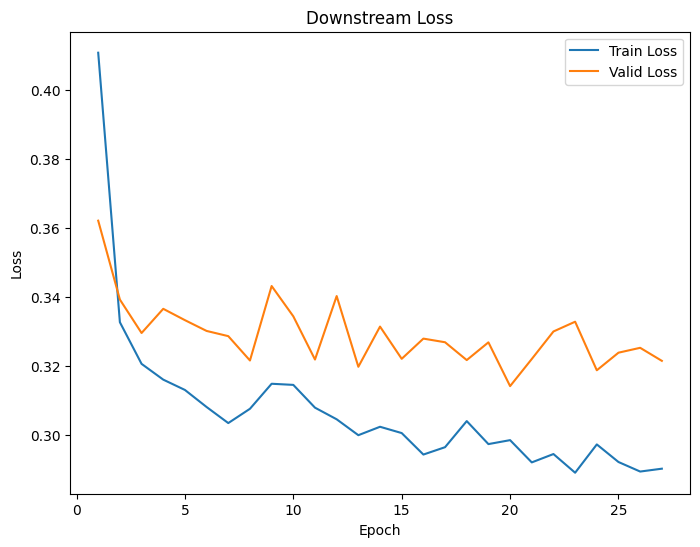

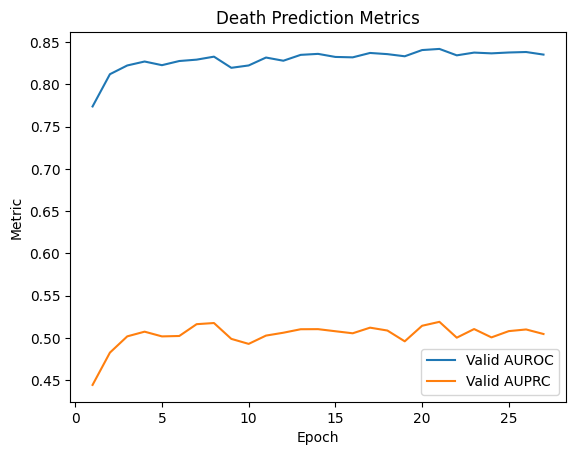

In [20]:

model = STraTSModel(num_features=num_features, embed_dim=embed_dim, num_heads=num_heads,
                    num_blocks=num_layers, ff_dim=ff_dim, dropout=dropout, activation=activation, final_emb_type=final_emb_type).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4)
model.load_state_dict(torch.load('best_pretrained_model.pt'))
df_downstream_loss = train_model(model, train_loader, valid_loader, epochs=1000, optimizer=optimizer, 
                                 device=device, mask_rate=0.2, seed=42)

In [21]:
metrics = evaluate_model(model, test_loader, device)
print("Test Metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

Test Metrics:
AUROC: 0.8420
AUPRC: 0.4983
Precision: 0.6493
Recall: 0.2635
F1: 0.3748
Accuracy: 0.8776


[Downstream] Epoch [1/1000] - Training:   0%|          | 0/189 [00:00<?, ?it/s]

[Downstream] Epoch [1/1000] - Validation:   0%|          | 0/48 [00:00<?, ?it/s]

[Epoch 1] Train Loss=0.7413, Valid Loss=0.7320, Valid AUROC=0.6928, AUPRC=0.3203


[Downstream] Epoch [2/1000] - Training:   0%|          | 0/189 [00:00<?, ?it/s]

[Downstream] Epoch [2/1000] - Validation:   0%|          | 0/48 [00:00<?, ?it/s]

...

[Downstream] Epoch [7/1000] - Validation:   0%|          | 0/48 [00:00<?, ?it/s]

[Epoch 7] Train Loss=0.7413, Valid Loss=0.7320, Valid AUROC=0.6928, AUPRC=0.3203


[Downstream] Epoch [8/1000] - Training:   0%|          | 0/189 [00:00<?, ?it/s]

[Downstream] Epoch [8/1000] - Validation:   0%|          | 0/48 [00:00<?, ?it/s]

[Epoch 8] Train Loss=0.7403, Valid Loss=0.7320, Valid AUROC=0.6928, AUPRC=0.3203
Early stopping triggered (downstream).


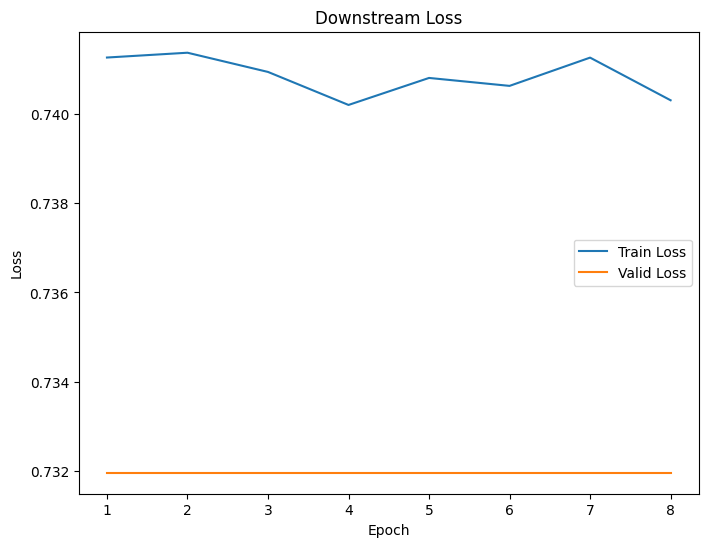

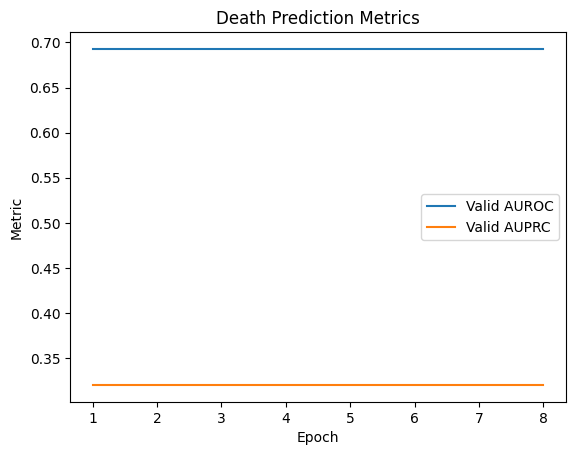

In [22]:
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4)
model = STraTSModel(num_features=num_features, embed_dim=embed_dim, num_heads=num_heads,
                    num_blocks=num_layers, ff_dim=ff_dim, dropout=dropout, activation=activation, final_emb_type=final_emb_type).to(device)

model.load_state_dict(torch.load("best_pretrained_model.pt"))

df_downstream_loss_frozen = train_model(model, train_loader, valid_loader, epochs=1000, optimizer=optimizer, 
                                 device=device, mask_rate=0.2, seed=42, freeze=True)

In [23]:
metrics = evaluate_model(model, test_loader, device)
print("Test Metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

Test Metrics:
AUROC: 0.7134
AUPRC: 0.3151
Precision: 0.1698
Recall: 0.8981
F1: 0.2856
Accuracy: 0.3742


In [24]:
try:
    df_downstream_results = validate_model_downstream(model, valid_loader, device=device, mask_rate=0.2, seed=42)
except:
    print('Something went wrong with the validating function.')


Something went wrong with the validating function.


In [25]:
for param in model.time_embed.parameters():
    print(param)


Parameter containing:
tensor([[ 0.0031, -0.9224,  0.0165,  1.0635, -0.0011]], device='cuda:0')
Parameter containing:
tensor([-0.9945, -0.1067,  0.0074,  0.3028,  1.4325], device='cuda:0')
Parameter containing:
tensor([[ 0.1478,  0.3886, -0.4596, -0.5058, -0.6080,  0.0805,  0.1852, -0.5763,
          0.2201,  0.4392,  0.0534, -0.3388, -0.1013,  0.3315,  0.3436, -0.4349,
         -0.2418, -0.4240,  0.4932, -0.4326, -0.4576, -0.0831,  0.3823, -0.4363,
          0.0442,  0.3620,  0.7199,  0.1746,  0.3753,  0.2004, -0.3116,  0.8513],
        [-0.2419,  0.1859,  0.1870, -0.2052,  0.0294, -0.0692, -0.2819, -0.3620,
         -0.0370, -0.1396,  0.1310, -0.1798,  0.2252,  0.1381, -0.0173, -0.0295,
         -0.1030, -0.2843,  0.0044, -0.2061,  0.3983, -0.1368, -0.3298, -0.0546,
         -0.3291,  0.1942,  0.2608,  0.3666,  0.3418, -0.0630,  0.2866, -0.1361],
        [ 0.1040,  0.1423, -0.1594, -0.3889, -0.2766,  0.1590,  0.1491, -0.1144,
         -0.1305, -0.3073,  0.0116, -0.4231, -0.0286, -0.19

In [26]:
version = '1task426432'
df_downstream_loss.to_csv(f'downstream_loss_{version}.csv')
df_downstream_loss_frozen.to_csv(f'downstream_loss_frozen_{version}.csv')
df_pretrain_results.to_csv(f'pretrain_results_{version}.csv')

NameError: name 'df_pretrain_results' is not defined